<a href="https://colab.research.google.com/github/Antonyus1204/Proyecto_grupal_BIO218/blob/Proyecto-ConchaNegra-BIO218/Proyecto_grupal_BIO218.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Grupal Colaborativo — BIO 218
## Relación entre tamaño y peso en Anadara tuberculosa (concha negra)

**Integrantes:** Castillo Jamel Alejandra, Castillo Ashly Marieth, De Gracia Yahelys, Donoso David Antonio, Gill Liz Denis, Castillo Francia.

## Problema biológico
En bivalvos como *Anadara tuberculosa*, el crecimiento de la concha suele
acompañarse de un aumento en la masa corporal del organismo, pero se
desconoce con qué fuerza se relacionan ambas variables, y si esa relación
permite estimar el peso de forma confiable a partir del tamaño externo.

## Pregunta de investigación
¿Existe relación entre el tamaño (largo de la concha) y el peso del
organismo en *Anadara tuberculosa*?

## Hipótesis
- **H₁:** Existe una correlación positiva entre el largo de la concha y
  el peso del organismo (a mayor tamaño, mayor peso).
- **H₀:** No existe correlación entre el largo de la concha y el peso
  del organismo.

## Variables

| Variable | Tipo | Unidad | Papel |
|---|---|---|---|
| Largo de la concha | Cuantitativa continua | cm | Independiente |
| Peso del organismo | Cuantitativa continua | g | Dependiente |
| Circunferencia | Cuantitativa continua | cm | Apoyo |
| Talla | Cualitativa ordinal | Pequeña/Mediana/Grande | Apoyo |

---
### Importación de librerías

In [1]:
# ============================================================
# CELDA 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# NumPy permite generar números aleatorios con distribuciones estadísticas
# (como la normal) y hacer cálculos numéricos sobre conjuntos de datos completos.
import numpy as np

# Pandas se utiliza para organizar los datos en un DataFrame.
import pandas as pd

# Matplotlib se utiliza para construir visualizaciones científicas.
import matplotlib.pyplot as plt

# Confirmamos que el entorno quedó preparado.
print("Entorno de análisis preparado correctamente.")

Entorno de análisis preparado correctamente.


## Generación del dataset simulado

El dataset es completamente simulado mediante Python (n = 200), calibrado
con literatura biométrica de referencia de la especie para que la
simulación sea biológicamente realista, sin utilizar datos de campo reales.

El peso se calcula a partir de una relación **alométrica** (no lineal) con
el largo, ya que en organismos que crecen en volumen el peso aumenta más
rápido que el tamaño lineal.

In [2]:
# ============================================================
# CELDA 2. GENERACIÓN DEL DATASET SIMULADO
# ============================================================
# Fijamos una semilla para que la simulación sea reproducible.
np.random.seed(42)

# Definimos el número de observaciones (individuos simulados).
n = 200

# Simulamos el largo de la concha (cm) con distribución normal.
# Rango ajustado (4.0–7.0 cm) para alinearse con literatura biométrica de referencia.
largo = np.random.normal(loc=5.6, scale=0.8, size=n)
largo = np.clip(largo, 4.0, 7.0)

# Peso (g): ecuación de crecimiento alométrico publicada por Del Cid et al. (2021)
# para A. tuberculosa en el Estero Caté, Golfo de Montijo
ruido = np.random.normal(0, 8.5, n)
peso = 0.3431 * (largo ** 2.9334) + ruido
peso = np.clip(peso, 10.5, 126.2)

# Calculamos la circunferencia de la concha, proporcional al largo, con variación propia.
circunferencia = 2.6 * largo + np.random.normal(0, 0.6, n)

# Definimos una función para clasificar la talla comercial según el peso.
def clasificar_talla(p):
    if p < 45:
        return "Pequeña"
    elif p < 65:
        return "Mediana"
    else:
        return "Grande"

talla = [clasificar_talla(p) for p in peso]

df = pd.DataFrame({
    "id": range(1, n+1),
    "largo_cm": largo.round(2),
    "peso_g": peso.round(1),
    "circunferencia_cm": circunferencia.round(2),
    "talla": talla
})

df.to_csv("concha_negra_simulada.csv", index=False)
print("Dataset generado y guardado como concha_negra_simulada.csv")
print("Dimensiones:", df.shape)

Dataset generado y guardado como concha_negra_simulada.csv
Dimensiones: (200, 5)


## Primera inspección del dataset

Revisamos la estructura general (`head`, `info`) y el resumen estadístico
(`describe`) para confirmar que el dataset se generó correctamente, sin
valores faltantes y con variación realista entre observaciones.

In [3]:
# ============================================================
# CELDA 3. PRIMERA INSPECCIÓN DEL DATASET
# ============================================================
# head() muestra las primeras cinco observaciones.
display(df.head())

# info() resume tipos de datos y valores no nulos.
df.info()

# describe() genera un resumen estadístico de las variables numéricas.
display(df.describe().round(2))

,id,largo_cm,peso_g,circunferencia_cm,talla
0,1,6.00,68.7,14.64,Grande
1,2,5.49,55.4,13.91,Mediana
2,3,6.12,78.9,15.91,Grande
3,4,6.82,104.7,17.76,Grande
4,5,5.41,36.9,13.80,Pequeña


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 200 non-null    int64  
 1   largo_cm           200 non-null    float64
 2   peso_g             200 non-null    float64
 3   circunferencia_cm  200 non-null    float64
 4   talla              200 non-null    object 
dtypes: float64(3), int64(1), object(1)
memory usage: 7.9+ KB


,id,largo_cm,peso_g,circunferencia_cm
count,200.00,200.00,200.00,200.00
mean,100.50,5.56,55.79,14.40
std,57.88,0.71,22.52,1.87
min,1.00,4.00,10.50,9.66
25%,50.75,5.04,40.45,12.94
50%,100.50,5.60,55.55,14.50
75%,150.25,6.00,68.00,15.68
max,200.00,7.00,114.20,18.89


## Verificación visual de la relación (largo vs. peso)

Antes de aplicar cualquier prueba estadística, revisamos con un gráfico
de dispersión si la relación entre largo y peso es curva o recta. Esto
determina si es necesario transformar los datos a logaritmo antes de
calcular la correlación (ver estrategia de análisis).

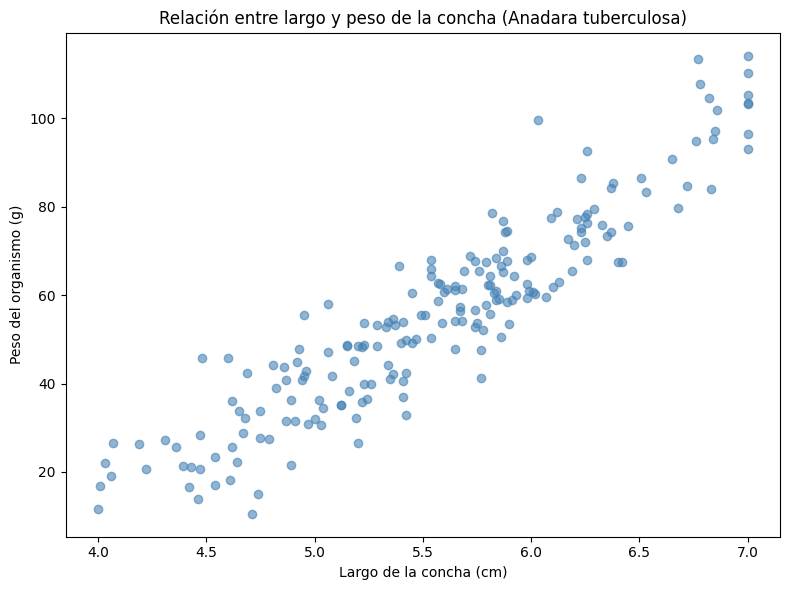

In [4]:
# ============================================================
# CELDA 4. SCATTERPLOT: LARGO VS. PESO
# ============================================================

# Creamos la figura.
plt.figure(figsize=(8, 6))

# Dibujamos la relación entre largo y peso.
plt.scatter(df["largo_cm"], df["peso_g"], alpha=0.6, color="steelblue")

# Añadimos título y etiquetas.
plt.title("Relación entre largo y peso de la concha (Anadara tuberculosa)")
plt.xlabel("Largo de la concha (cm)")
plt.ylabel("Peso del organismo (g)")

# Ajustamos el diseño y mostramos la figura.
plt.tight_layout()
plt.show()

## Comparación de modelos: lineal vs. logarítmico

Aunque se esperaba una relación curva por tratarse de crecimiento
alométrico, el scatterplot mostró una curvatura poco pronunciada dentro
del rango de tamaños simulado. En lugar de decidir solo por apariencia
visual, se comparó numéricamente qué tan bien explica cada modelo la
variación de los datos, usando el coeficiente de determinación (R²).

In [5]:
# ============================================================
# CELDA 5. COMPARACIÓN: AJUSTE LINEAL VS. LOGARÍTMICO
# ============================================================
from scipy import stats

# Ajuste lineal directo (largo vs peso)
slope_lin, intercept_lin, r_lin, p_lin, se_lin = stats.linregress(df["largo_cm"], df["peso_g"])

# Ajuste sobre datos transformados a logaritmo
log_largo = np.log(df["largo_cm"])
log_peso = np.log(df["peso_g"])
slope_log, intercept_log, r_log, p_log, se_log = stats.linregress(log_largo, log_peso)

# Comparamos qué tan bien explica cada modelo la variación (R²)
print("Modelo lineal (largo vs peso):      R² =", round(r_lin**2, 4))
print("Modelo logarítmico (log-log):        R² =", round(r_log**2, 4))

Modelo lineal (largo vs peso):      R² = 0.858
Modelo logarítmico (log-log):        R² = 0.815


## Estrategia preliminar de análisis

**1. ¿Cuál es nuestra pregunta?**
¿Existe relación entre el largo de la concha (cm) y el peso del organismo (g)?

**2. Variable dependiente:** Peso (g)

**3. Variable independiente:** Largo de la concha (cm)

**4. Tipo de variables:** Ambas cuantitativas continuas

**5. Grupos comparados:** Ninguno ( buscamos asociación, no diferencia entre categorías)

**6. Supuestos verificados:** linealidad (scatterplot, Celda 4), comparación
numérica lineal vs. logarítmico (Celda 5), normalidad pendiente de verificar
con Shapiro-Wilk en el siguiente hito.

**7. Método seleccionado:** El modelo lineal obtuvo un R² de 0.858, superior
al logarítmico (R² = 0.815), por lo que se utilizará correlación de Pearson
y regresión lineal simple, sin transformación logarítmica